### Imports and Constants

In [49]:
import sys
sys.path.append('../')

from gam_rs_utils.utils import *
from method_scripts.results import Results

In [50]:
SUPPORT_SET_METRICS = [Metrics.inverse_IoU, Metrics.euclidean_distance, Metrics.inverse_cosine_similarity]
LOSS_METRICS = ['accuracy', 'logistic']
LOGIT_METRICS = [Metrics.compute_logit_variance, Metrics.compute_logit_pairwise_distance]
PREDICTION_METRICS = [Metrics.hamming_distance]

def collate_datasets_results():
    all_datasets_results = {}
    for dn in DATASET_NAMES:
        runs = list()
        runs_paths = os.listdir(f"../results/{dn}/method_results")
        runs_paths.sort()
        for fn in runs_paths:
            result = Results.load_result(f"../results/{dn}/method_results/{fn}")
            runs.append(result.to_dataframe_row())
        all_datasets_results[dn] = pd.concat(runs, axis=0, ignore_index=True)
    return all_datasets_results

def compute_feature_specific_metrics(new_cols, bin_X, bin_header, w_rset, n_samples):
    # compute feature-specific metrics
    new_cols['feature_to_variable_importance'] = Plotter.get_variable_importance(
        bin_X,
        w_rset[:, 1:],
        np.array(bin_header[1:]),
    )

    # compute variable importance for each feature
    feature_indices = ModelUtils.get_feature_indices(bin_header)
    feature_widths = ModelUtils.get_feature_widths(bin_header)

    feature_logit_difference = defaultdict(list)
    feature_shape_difference = defaultdict(list)
    for feature, indices in feature_indices.items():
        indices = np.array(indices)
        feature_logit_difference[feature].append(Metrics.average_pairwise_diversity(
            w_rset[:, indices], 
            Metrics.logit_difference, 
            limit=n_samples, 
            X=bin_X[:, indices]
        ))
        feature_shape_difference[feature].append(Metrics.average_pairwise_diversity(
            w_rset[:, indices], 
            Metrics.shape_difference, 
            limit=n_samples, 
            X=feature_widths[feature]
        ))
    new_cols['feature_logit_difference'].append(feature_logit_difference)
    new_cols['feature_shape_difference'].append(feature_shape_difference)

def populate_datasets_results(all_datasets_results, n_samples):
    # do hamming, model count, 
    for dn, df in all_datasets_results.items():
        new_cols = defaultdict(list)
        for i, row in df.iterrows():
            # load rashomon set for this run
            w_rset = row['w_rset']
            idx = np.random.choice(w_rset.shape[0], size=n_samples, replace=False)
            w_rset = w_rset[idx]
            w_opt = row['w_opt']
            l0 = row['l0']
            l2 = row['l2']
            method_type = row['method_type']

            # load dataset used for this run
            dataset = Results.load_dataset(f"../results/{dn}", {'l0': l0, 'l2': l2})
            bin_X = dataset['bin_X']
            y = dataset['y']
            bin_header = dataset['bin_header']
            cum_header = dataset['cum_header']

            # compute diversity metrics on the support set
            for metric in SUPPORT_SET_METRICS:
                average_diversity = Metrics.average_pairwise_diversity(w_rset, metric, limit=n_samples)
                new_cols[metric.__name__].append(average_diversity)
            
            # compute loss values
            for metric in LOSS_METRICS:
                losses, opt_loss = ModelUtils.get_loss(bin_X, y, w_rset, loss_type=metric, w_opt=w_opt, l2=l2)
                new_cols[metric].append(losses)
                new_cols[metric + '_opt'].append(opt_loss)

            # compute logit metrics
            logits = bin_X @ w_rset.T
            for metric in LOGIT_METRICS:
                new_cols[metric.__name__].append(metric(logits))

            # compute prediction metrics
            predictions = ModelUtils.get_predictions(bin_X, w_rset)
            for metric in PREDICTION_METRICS:
                average_diversity = Metrics.average_pairwise_diversity(predictions.T, metric, limit=n_samples)
                new_cols[metric.__name__].append(average_diversity)

            # compute feature-specific metrics
            compute_feature_specific_metrics(new_cols, bin_X, bin_header, w_rset, n_samples)
            print(new_cols)


        # add new_cols to df
        for key, value in new_cols.items():
            df[key] = value

### Compute All Metrics

In [15]:
n_samples = 100
all_datasets_results = collate_datasets_results()

In [16]:
populate_datasets_results(all_datasets_results, n_samples)

loading dataset from ../results/bank/l0_0.001_l2_0.001.pkl
defaultdict(<class 'list'>, {'inverse_IoU': [(0.0, array([0., 0.]))], 'euclidean_distance': [(56.23548391239539, array([56.23548391, 56.23548391]))], 'inverse_cosine_similarity': [(0.35620329044439175, array([0.35620329, 0.35620329]))], 'accuracy': [[0.099535500995355, 0.0999778809997788, 0.09798717097987171, 0.09887193098871931, 0.10727715107277151, 0.11037381110373812, 0.10307454103074541, 0.0990931209909312, 0.09666003096660031, 0.09842955098429551, 0.1041804910418049, 0.0982083609820836, 0.10064145100641451, 0.0990931209909312, 0.11037381110373812, 0.1032957310329573, 0.10042026100420261, 0.1112585711125857, 0.09931431099314311, 0.10086264100862641, 0.10506525105065251, 0.0999778809997788, 0.10174740101747401, 0.10351692103516921, 0.09599646095996461, 0.10108383101083832, 0.1032957310329573, 0.09776598097765982, 0.11015262110152621, 0.09798717097987171, 0.10019907100199071, 0.0982083609820836, 0.1079407210794072, 0.09666003

KeyboardInterrupt: 

In [ ]:
with open(f'all_datasets_results.pkl', 'wb') as f:
    pickle.dump(all_datasets_results, f)

### Get Plotting Functions

In [ ]:
with open(f'../bank_results.pkl', 'rb') as f:
    all_datasets_results = pickle.load(f)

want_to_plot = [
    'ellipsoid surface (euclidean)',
    'mcmc random, sample 20.0',
    'mcmc correlation_swap, sample 20.0',
    'mcmc random_swap, sample 20.0',
    'mcmc same_feature_swap, sample 20.0',
    'mcmc multi_swap, sample 20.0',
    'mcmc feature_swap, sample 20.0',
    # 'mcmc random, sample 0.0',
    # 'mcmc correlation_swap, sample 0.0',
    # 'mcmc random_swap, sample 0.0',
    # 'mcmc same_feature_swap, sample 0.0'
    # 'mcmc multi_swap, sample 0.0',
    # 'mcmc feature_swap, sample 0.0',
    'swapping 3.0',
]
want_to_plot = [
    'ellipsoid surface (euclidean)',
    'mcmc swap, sample 20.0, incremental_cd',
    'mcmc swap, sample 20.0, standard',
    'mcmc correlation_swap, sample 20.0, incremental_cd',
    'mcmc correlation_swap, sample 20.0, standard',
    'mcmc multi_swap, sample 20.0, incremental_cd',
    'mcmc multi_swap, sample 20.0, standard',
    'mcmc same_feature_swap, sample 20.0, incremental_cd',
    'mcmc same_feature_swap, sample 20.0, standard',
    'mcmc feature_swap, sample 20.0, incremental_cd',
    'mcmc feature_swap, sample 20.0, standard',
    'swapping 3.0',
]
for dn, df in all_datasets_results.items():
    for i, row in df.iterrows():
        if want_to_plot and row['label'] not in want_to_plot:
            # print(f"dropping {row['label']}")
            df.drop(i, inplace=True)

In [52]:
# all_datasets_results['mimic2'].drop(17, inplace=True)
del all_datasets_results['spambase']
del all_datasets_results['mimic2']

In [53]:
def show_distributions(all_datasets_results, dn, loss_type):
    df = all_datasets_results[dn]
    plotter = MultiPlotter(title=f"{dn} - {loss_type} Loss Distributions")
    for i, row in df.iterrows():
        losses = row[loss_type]
        opt_loss = row[loss_type + '_opt'] if loss_type + '_opt' in row else None
        plotter.add_distribution(losses, row['label'], opt_loss)
    plotter.plot_distributions()

def get_bar_plot(all_datasets_results, metric):
    plotter = MultiPlotter(title=f"{metric} Bar Plot")
    for dname, df in all_datasets_results.items():
        labels = [row['label'] for _, row in df.iterrows()]
        list_of_mean_and_cis = df[metric].to_list()
        if metric in PREDICTION_METRICS:
            list_of_mean_and_cis = [Metrics.get_mean_and_ci(distribution) for distribution in list_of_mean_and_cis]
        if metric == 'runtime':
            list_of_mean_and_cis = [(r, (r, r)) for r in list_of_mean_and_cis]
        plotter.add_bar(list_of_mean_and_cis, dname, labels)
    fig = plotter.plot_bar_charts()
    return fig

def get_gam(all_datasets_results, dname, n_samples=50):
    plotter = MultiPlotter(title=f"GAM Shape Functions")
    df = all_datasets_results[dname]
    for i, row in df.iterrows():
        dataset = Results.load_dataset(f"../results/{dname}", {'l0': 0.001, 'l2': 0.001})
        plotter.add_shape_function(np.array(dataset['bin_header'][1:]), row['w_rset'][:n_samples, 1:], row['label'])
    fig = plotter.plot_shape_functions()
    return fig

def get_variable_importance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    plotter = MultiPlotter(title=f"Variable Importance Distributions")
    for i, row in df.iterrows():
        plotter.add_variable_importance_distribution(row['feature_to_variable_importance'], row['method'])
    fig = plotter.plot_variable_importance_distributions()
    return fig

def get_model_reliance(all_datasets_results, dname):
    df = all_datasets_results[dname]
    
    plotter = MultiPlotter(title=f"Model Reliance for {dname}")
    for i, row in df.iterrows():
        plotter.add_model_reliance(row['feature_to_variable_importance'], row['method'])
    fig = plotter.plot_model_reliance_violin_plots()
    return fig

def get_feature_to_shape_diversity(all_dataset_results, dname, metric):
    df = all_dataset_results[dname]

    plotter = MultiPlotter(title=f"{metric} for {dname}")
    for i, row in df.iterrows():
        plotter.add_shape_diversity(row[metric], row['method'])
    fig = plotter.plot_shape_diversity()
    return fig

def show_swapping_percentages(all_dataset_results, dname):
    df = all_dataset_results[dname]
    collated_swapping_percentages = []
    for i, row in df.iterrows():
        if row['method'].startswith("swapping"):
            collated_swapping_percentages.append(row['swapping_percentages'])

    swapping_methods = [m for m in methods if m.startswith("swapping")]
    plt.bar(swapping_methods, [np.average(p) for p in collated_swapping_percentages])
    plt.xticks(rotation=45)
    plt.title(f"Swapping Percentages")
    plt.tight_layout()
    plt.show()

    for sm, p in zip(swapping_methods, collated_swapping_percentages):
        plt.hist(p, bins=30)
        plt.title(f"{sm} - Swapping Percentages")
        plt.tight_layout()
        plt.show()

def get_table_results(all_dataset_results):
    details = ['dataset', 'method', 'runtime']
    distribution_metrics = ['accuracy', 'logistic']
    metrics = ['inverse_IoU', 'euclidean_distance', 'inverse_cosine_similarity'] #'compute_logit_variance', 'compute_logit_pairwise_distance', 'hamming']
    # feature_based_metrics = ['feature_to_shape_differences', 'feature_to_shape_diversities']

    combined_df = pd.DataFrame()
    for dname, df in all_dataset_results.items():
        df['method'] = [row['label'] for _, row in df.iterrows()]
        df = df[details + distribution_metrics + metrics].copy()
        df['runtime'] = df['runtime'].apply(lambda v: round(v, 3))
        df[distribution_metrics] = df[distribution_metrics].applymap(lambda v: round(np.average(v), 3))
        df[metrics] = df[metrics].applymap(lambda v: round(v[0], 3))
        combined_df = pd.concat([combined_df, df], ignore_index=True)
    return combined_df

### Visualizations

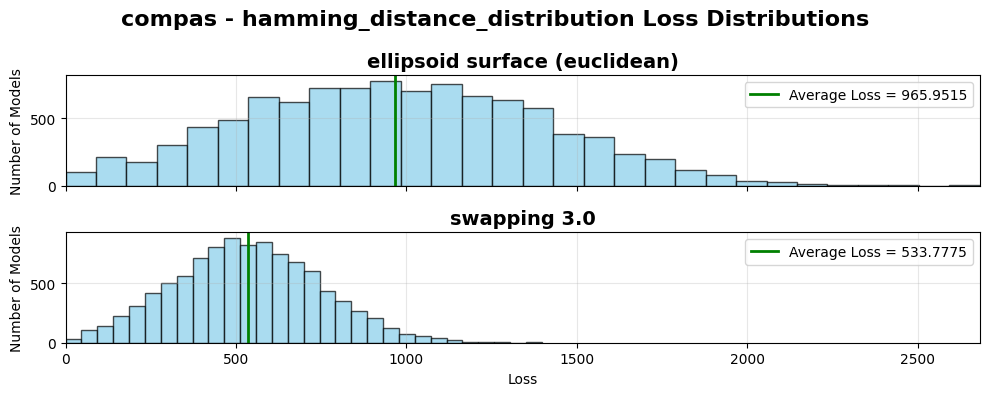

In [54]:
['accuracy', 'logistic', 'hamming_distance_distribution']
show_distributions(all_datasets_results, "compas", "hamming_distance_distribution")

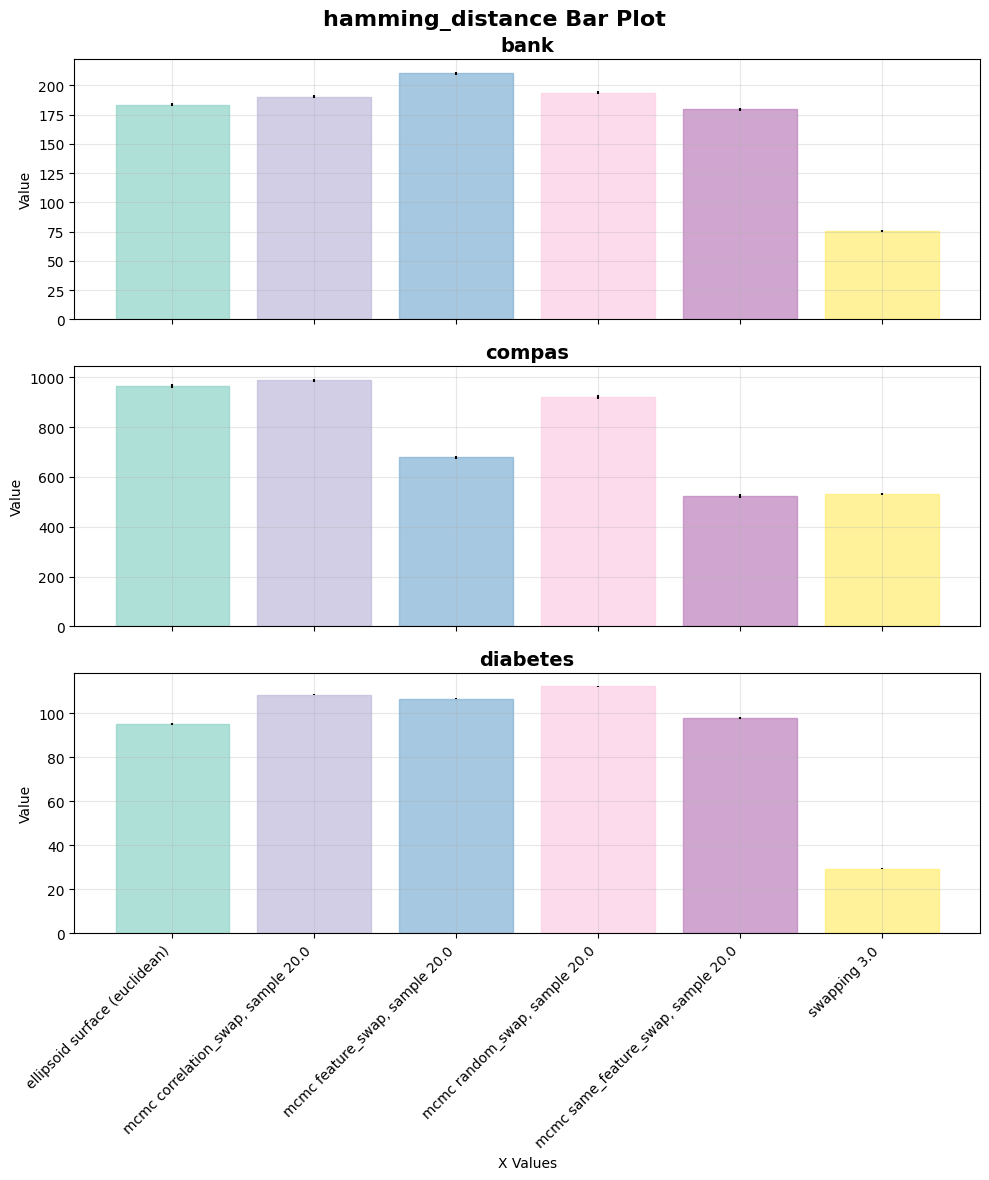

In [41]:
bar_metrics = [
    'runtime'
    'hamming_distance', 
    'inverse_IoU', 
    'euclidean_distance', 
    'inverse_cosine_similarity', 
    'compute_logit_variance', 
    'compute_logit_pairwise_distance'
]
bar_plot = get_bar_plot(all_datasets_results, 'hamming_distance')

loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl
loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl
loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl
loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl
loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl
loading dataset from ../results/diabetes/l0_0.001_l2_0.001.pkl


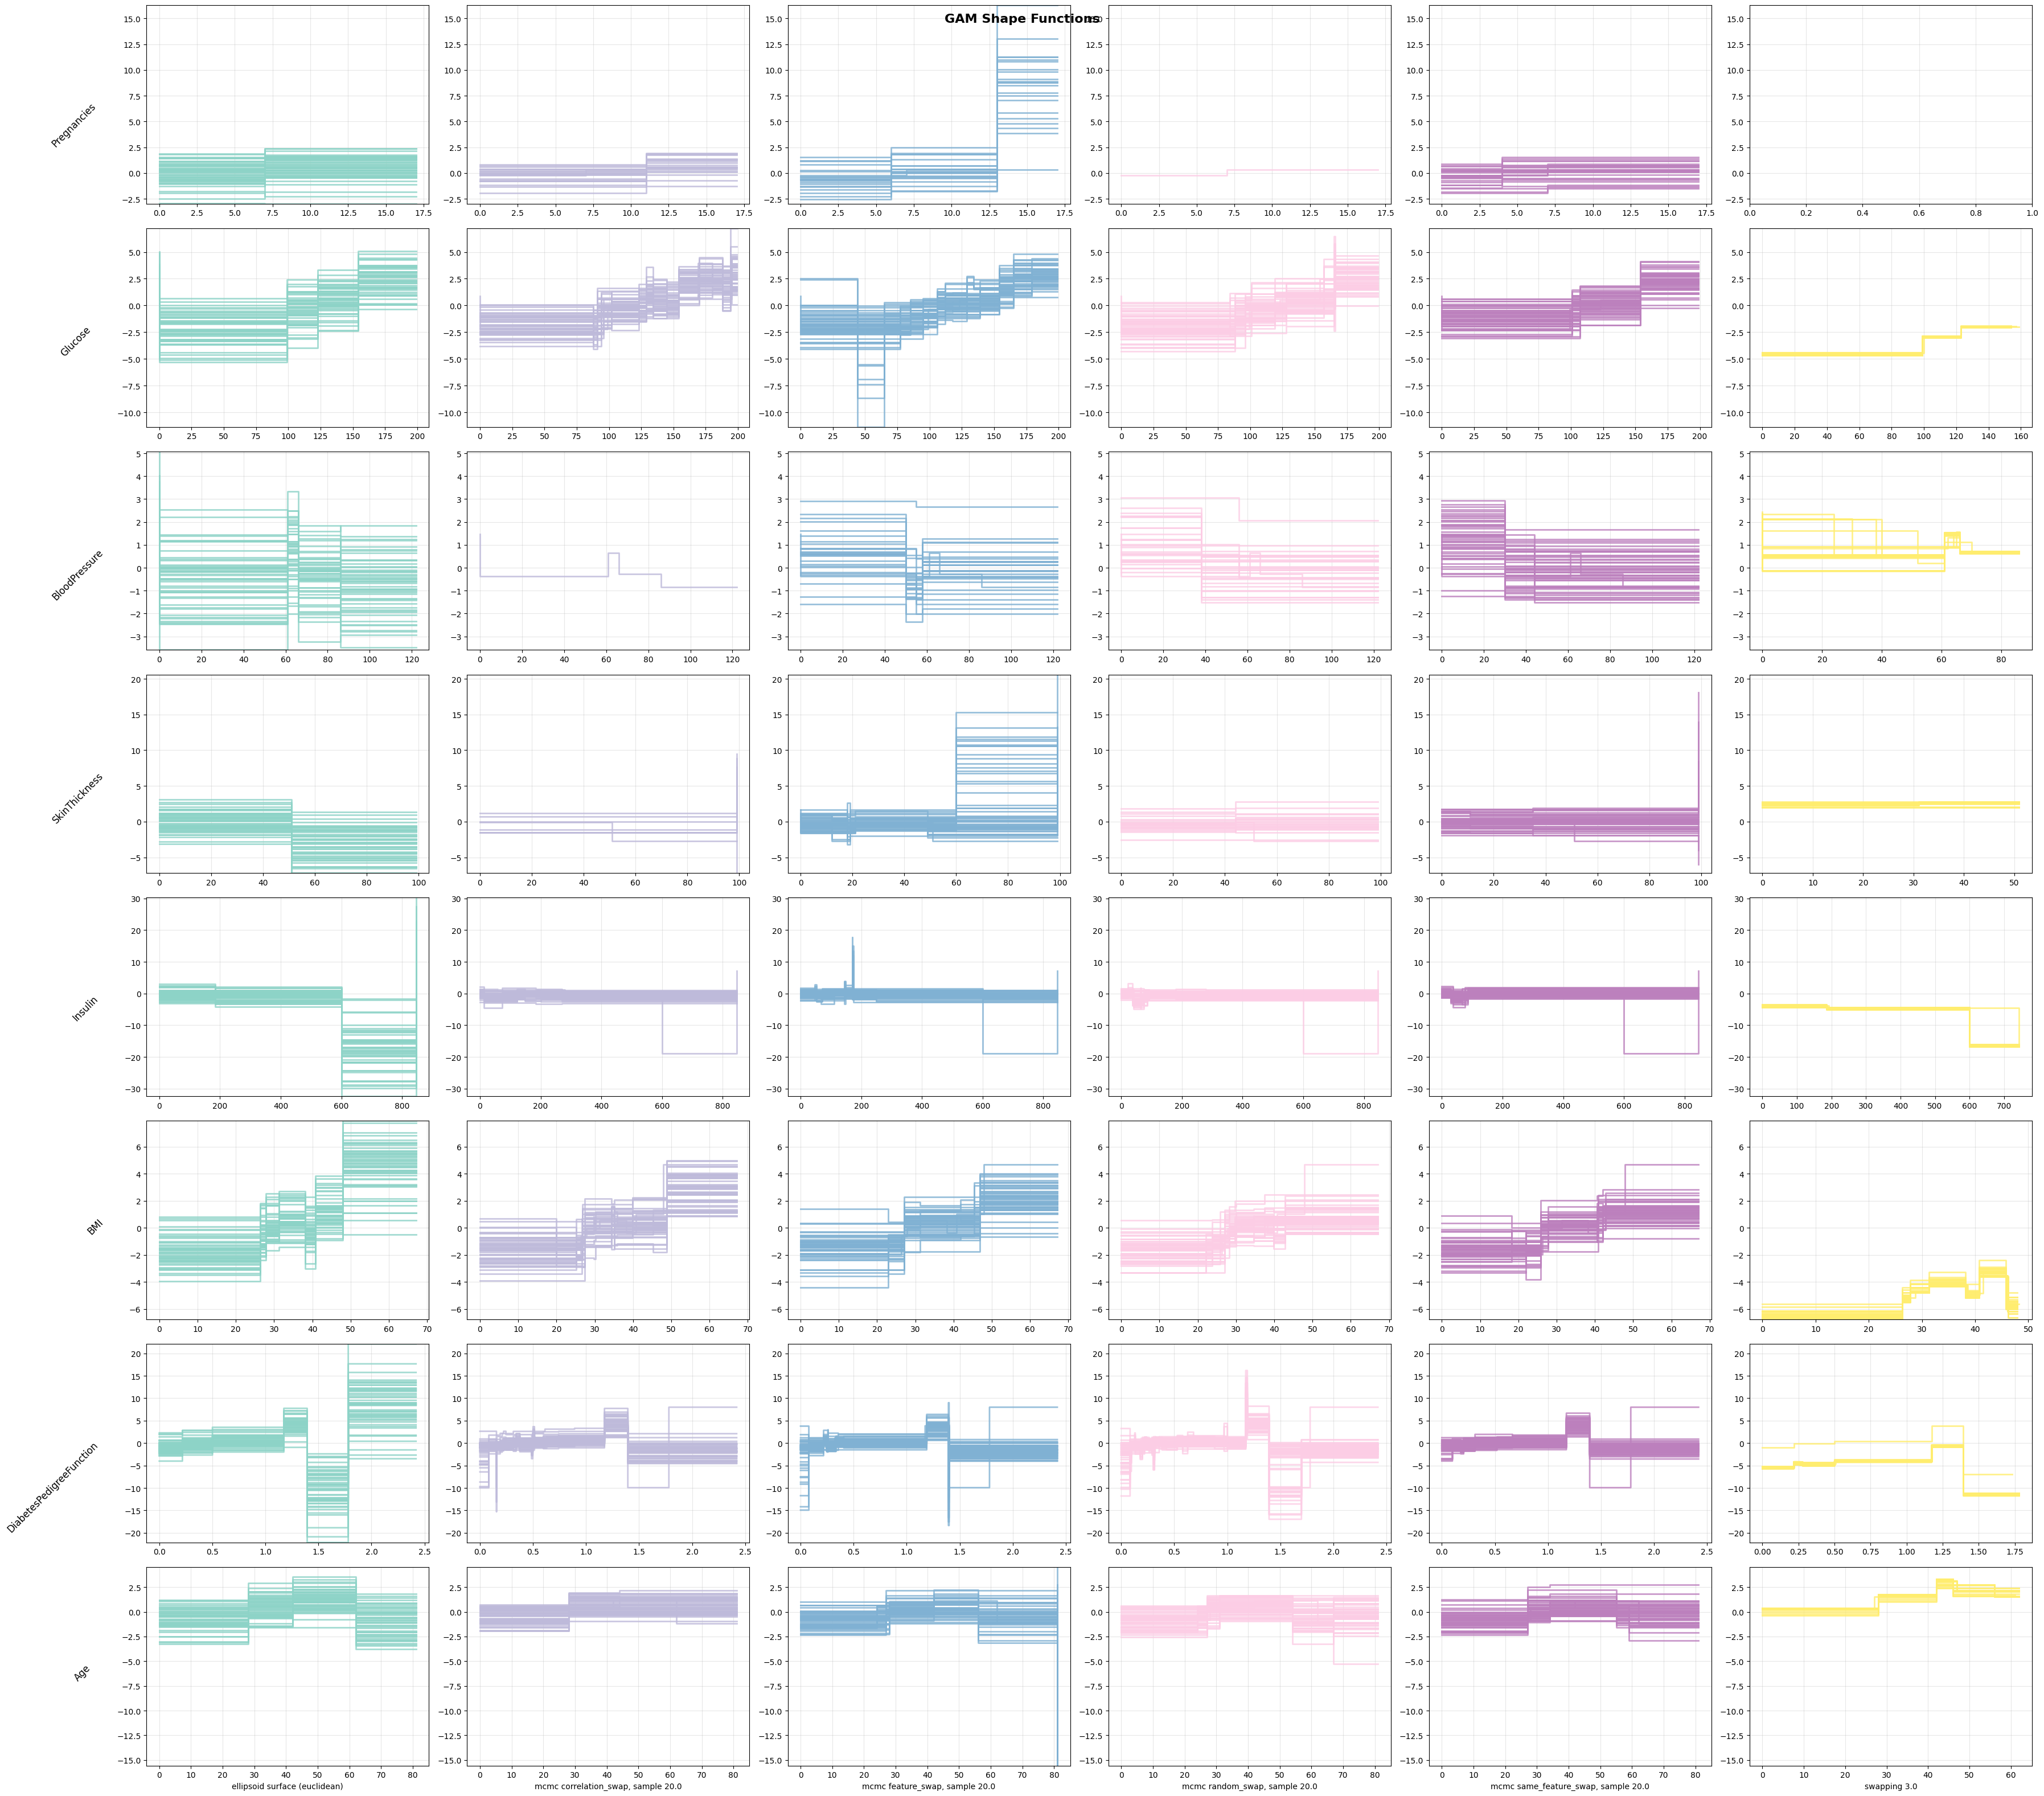

In [48]:
# ["bank", "compas", "diabetes", "spambase", "mimic2"]
gam = get_gam(all_datasets_results, 'diabetes')

In [10]:
variable_importance = get_variable_importance(all_datasets_results, 'bank')

AttributeError: 'float' object has no attribute 'keys'

In [13]:
model_reliance = get_model_reliance(all_datasets_results, "compas")

AttributeError: 'float' object has no attribute 'keys'

In [44]:
# ['feature_logit_difference', 'feature_shape_difference']
fsd = get_feature_to_shape_diversity(all_datasets_results, "bank", "feature_shape_difference")

KeyError: 'method'

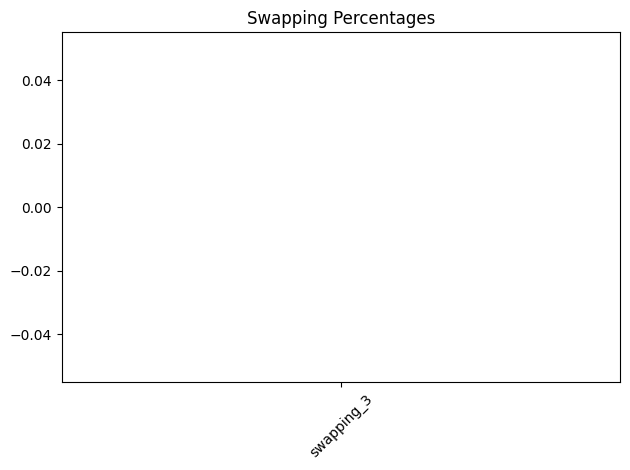

In [ ]:
# show_swapping_percentages(all_datasets_results, "bank")

In [6]:
get_table_results(all_datasets_results)

,dataset,method,runtime,accuracy,logistic,inverse_IoU,euclidean_distance,inverse_cosine_similarity
0,bank,ellipsoid surface (euclidean),8.360,0.101,0.276,0.000,58.243,0.368
1,bank,"mcmc correlation_swap, sample 20.0",69.501,0.103,0.273,0.311,82.066,0.501
2,bank,"mcmc feature_swap, sample 20.0",91.133,0.104,0.273,0.411,77.233,0.485
3,bank,"mcmc random_swap, sample 20.0",66.651,0.104,0.273,0.095,86.837,0.525
4,bank,"mcmc same_feature_swap, sample 20.0",86.740,0.103,0.273,0.002,56.765,0.371
5,bank,swapping 3.0,262.839,0.097,0.268,0.035,10.487,0.008
6,compas,ellipsoid surface (euclidean),18.980,0.330,0.619,0.000,15.404,0.434
7,compas,"mcmc correlation_swap, sample 20.0",72.751,0.329,0.617,0.053,16.435,0.494
8,compas,"mcmc feature_swap, sample 20.0",114.473,0.325,0.609,0.096,13.019,0.339
9,compas,"mcmc random_swap, sample 20.0",94.108,0.329,0.617,0.092,19.808,0.554


In [ ]:
bar_metrics = ['iou', 'euclidean']
for bm in bar_metrics:
    fig = get_bar_plot(all_datasets_results, bm, methods)  # this should create/return the figure
    fig.savefig(f'figures/{bm}_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names:
    fig = get_gam(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_gam.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for dn in dataset_names[1:]:
    fig = get_model_reliance(all_datasets_results, dn)
    fig.savefig(f'figures/{dn}_model_reliance.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
for fsd in feature_to_shape_metrics:
    fig = get_feature_to_shape_diversity(all_datasets_results, dn, fsd)
    fig.savefig(f'figures/{fsd}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)